
Loading TAIWAN dataset...
  -> Tuning Models...
  -> Initializing Explainers...
  -> Finding worst-case explanations for TAIWAN...


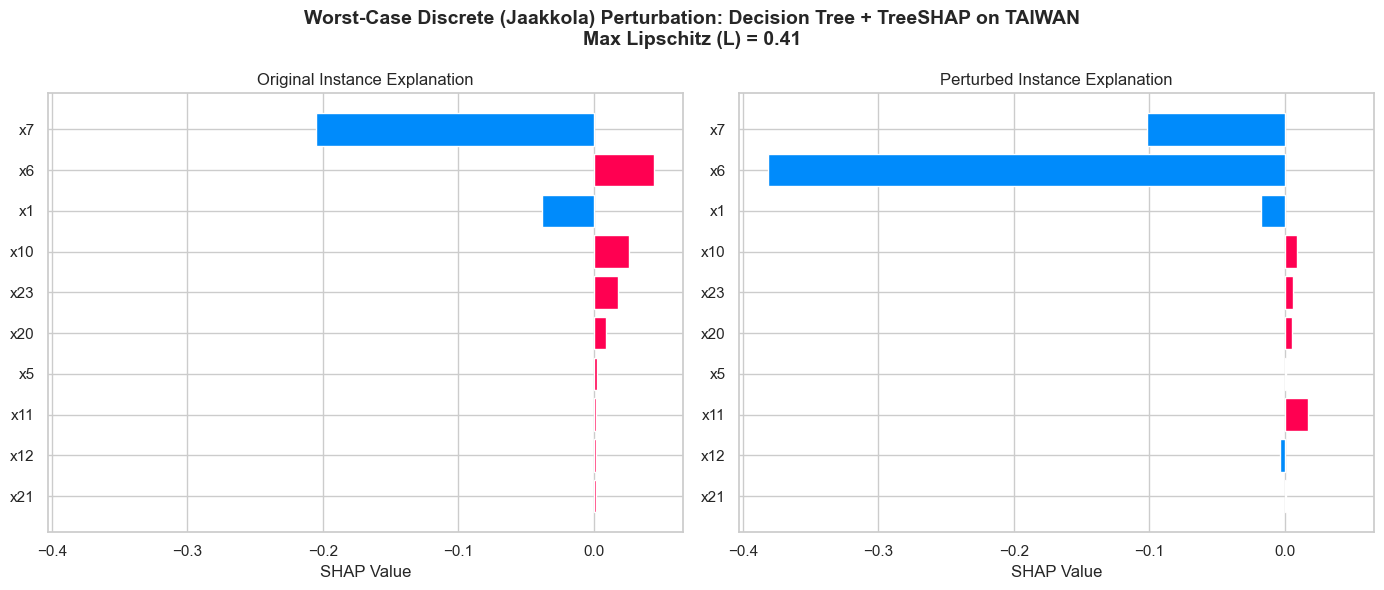

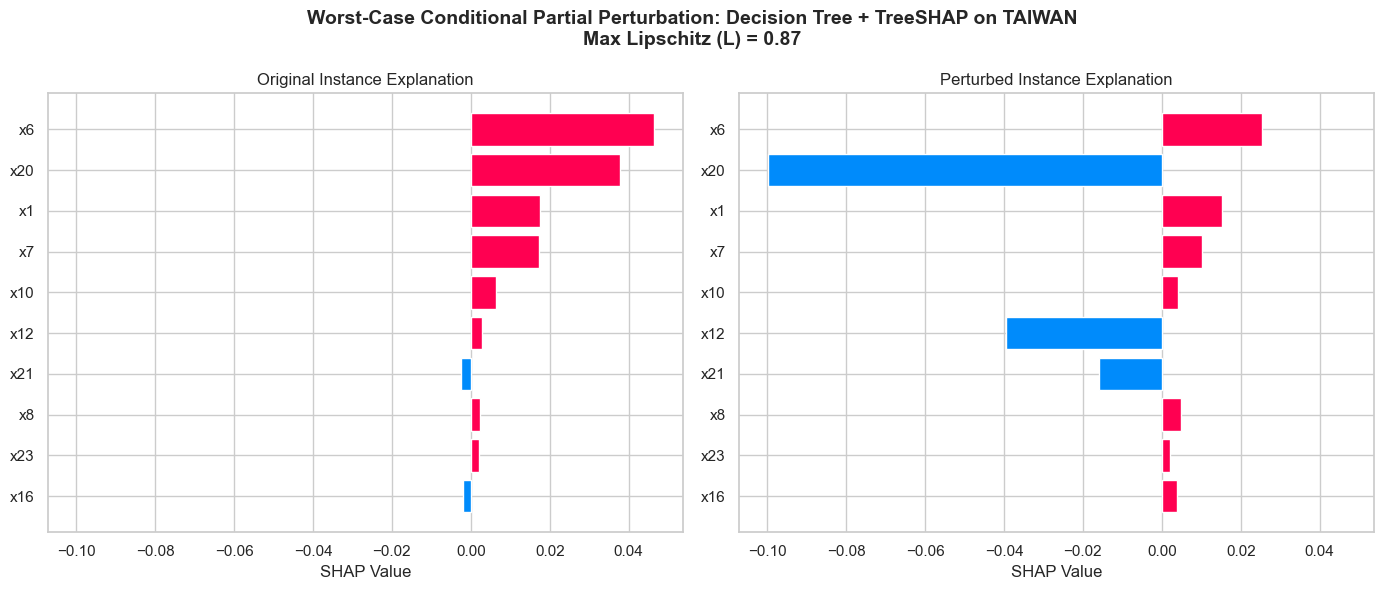

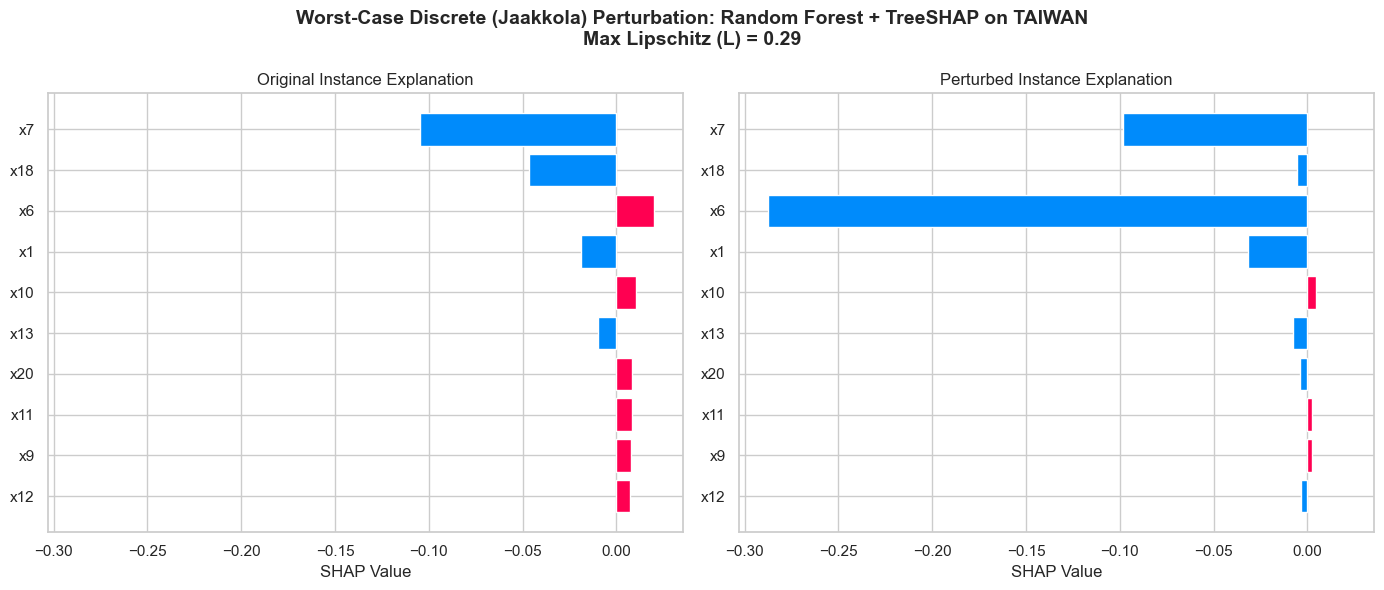

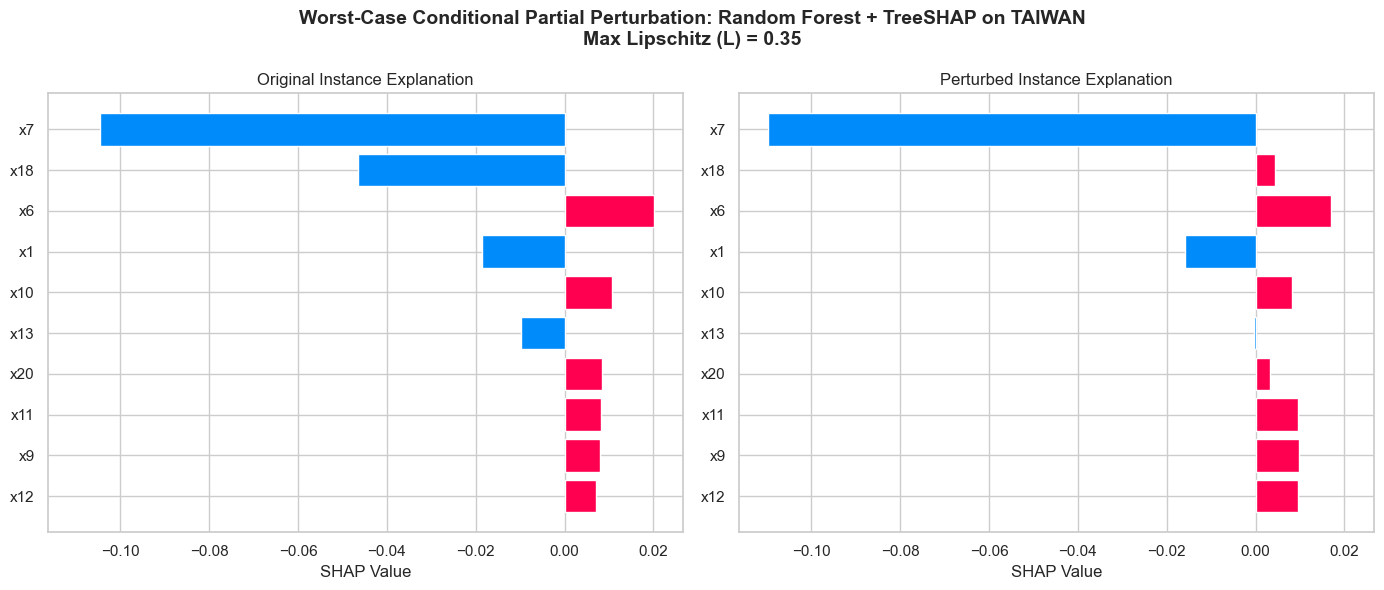

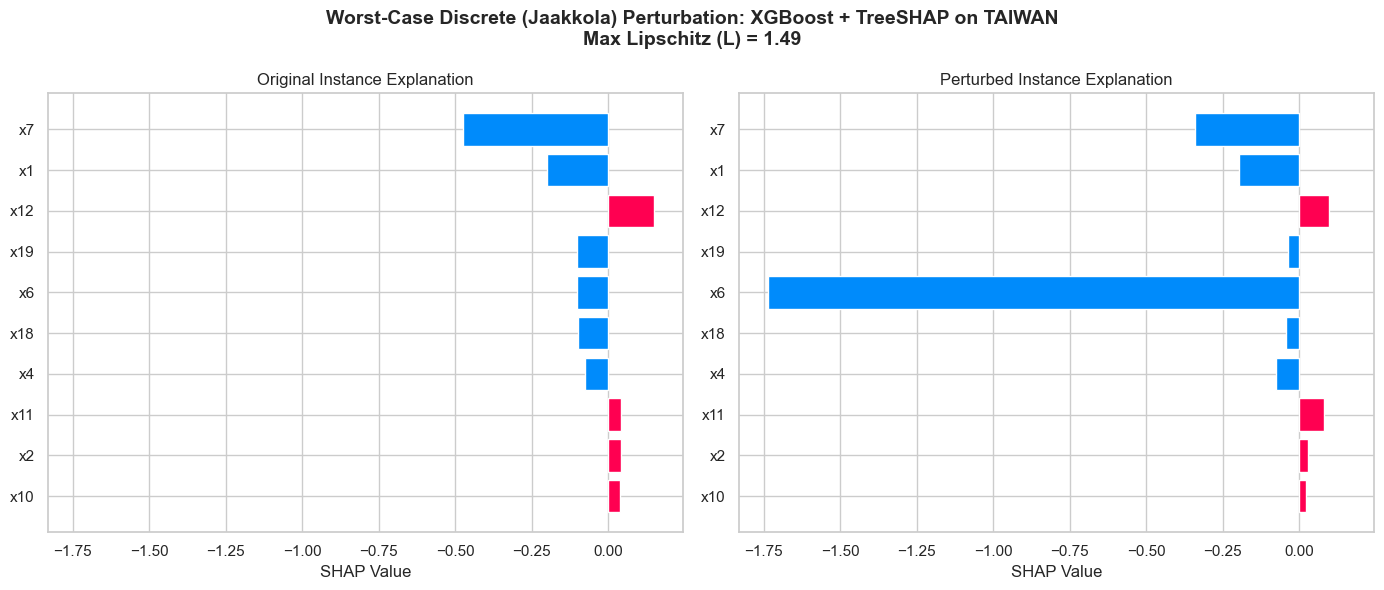

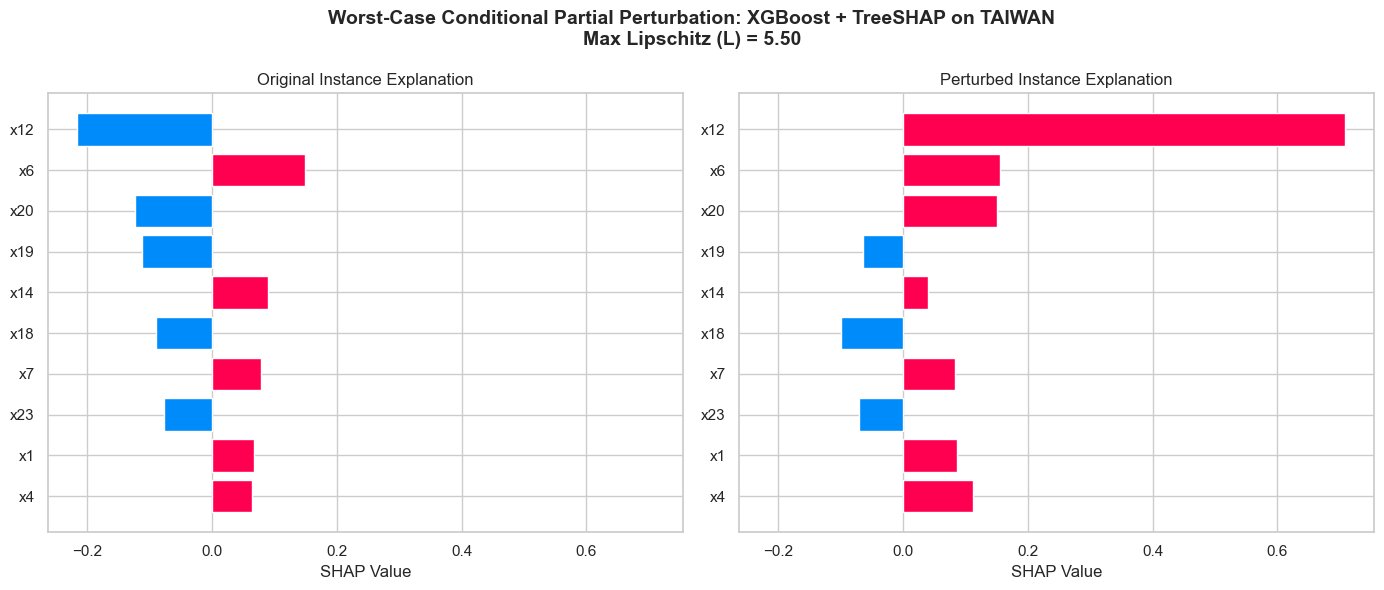

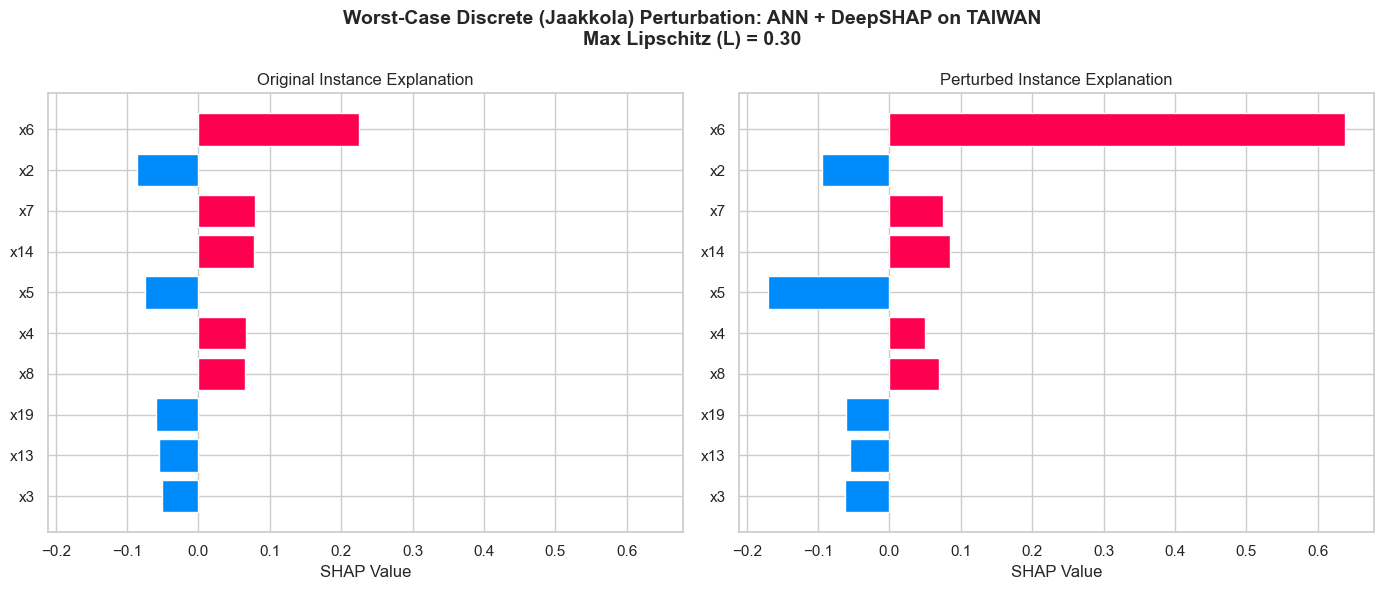

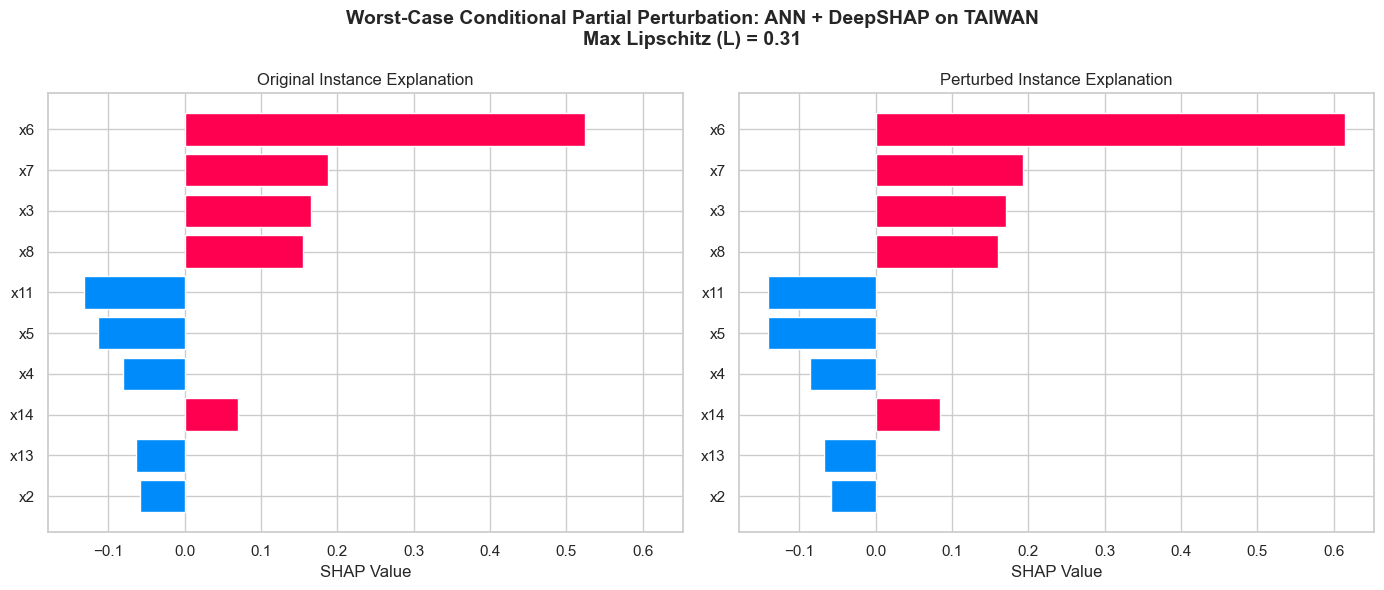


Loading COMPAS dataset...
  -> Tuning Models...
  -> Initializing Explainers...
  -> Finding worst-case explanations for COMPAS...


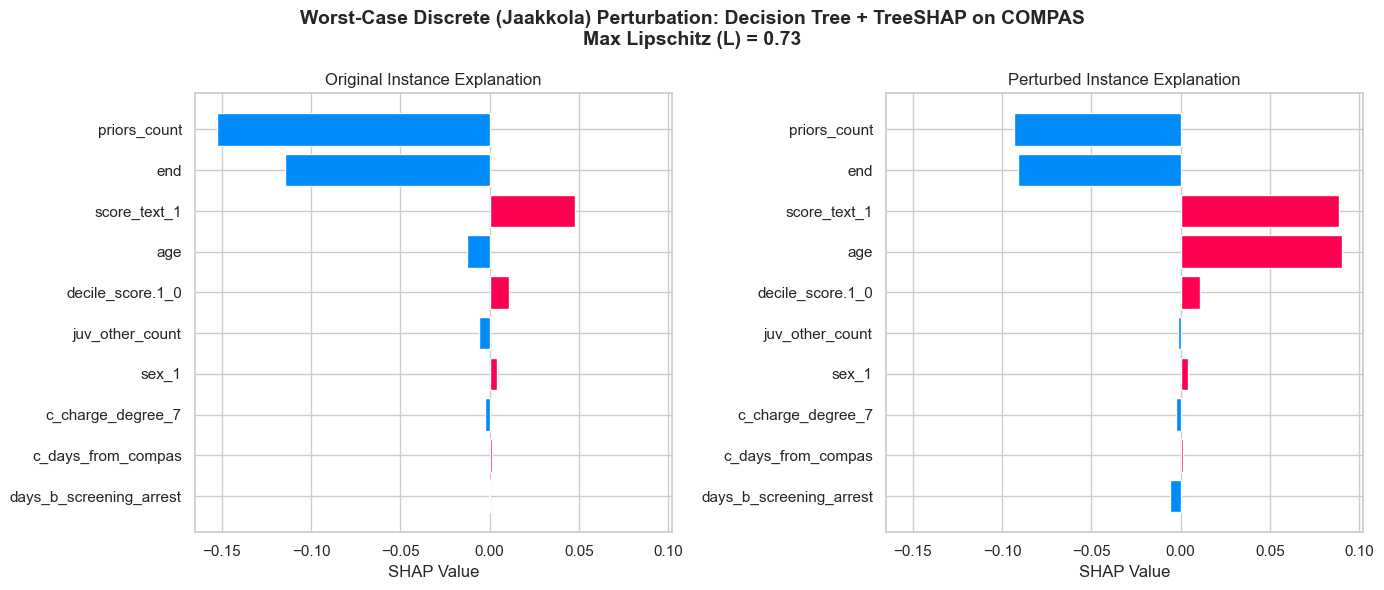

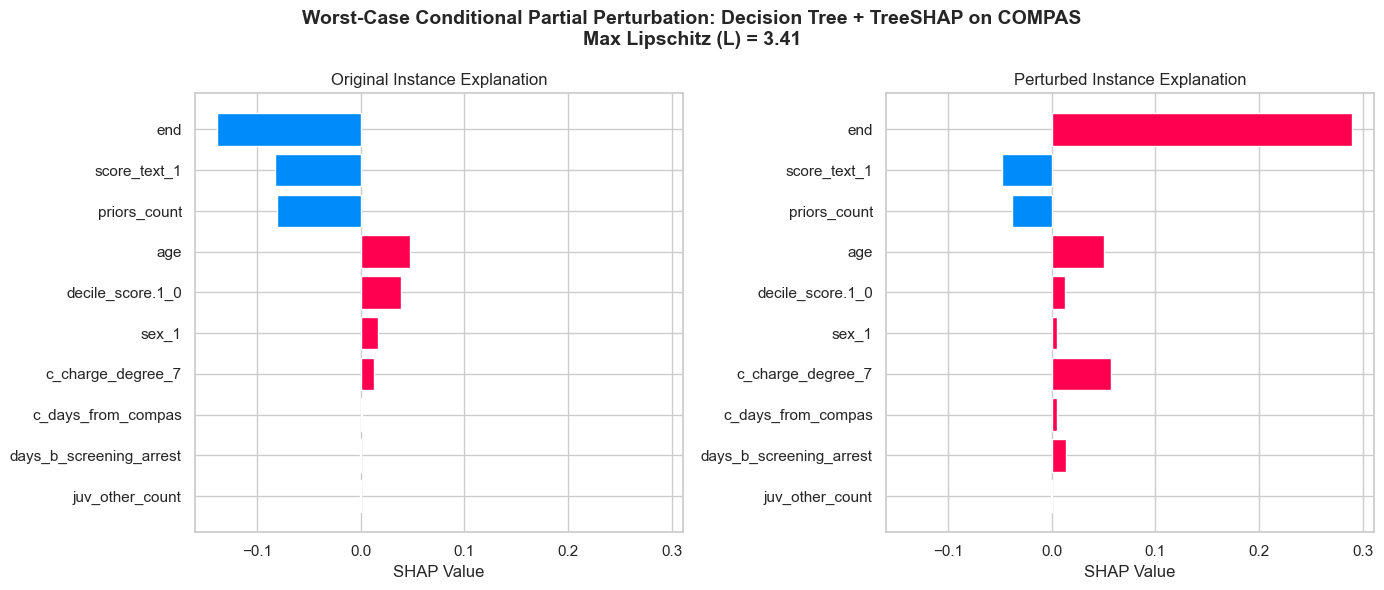

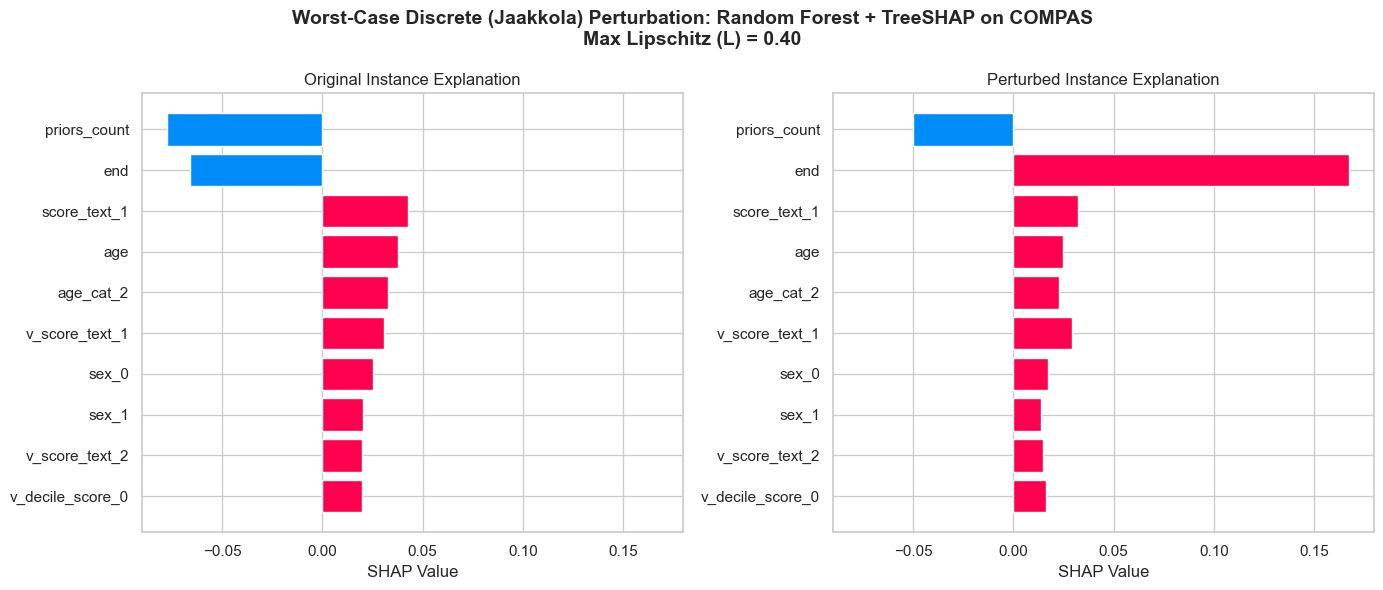

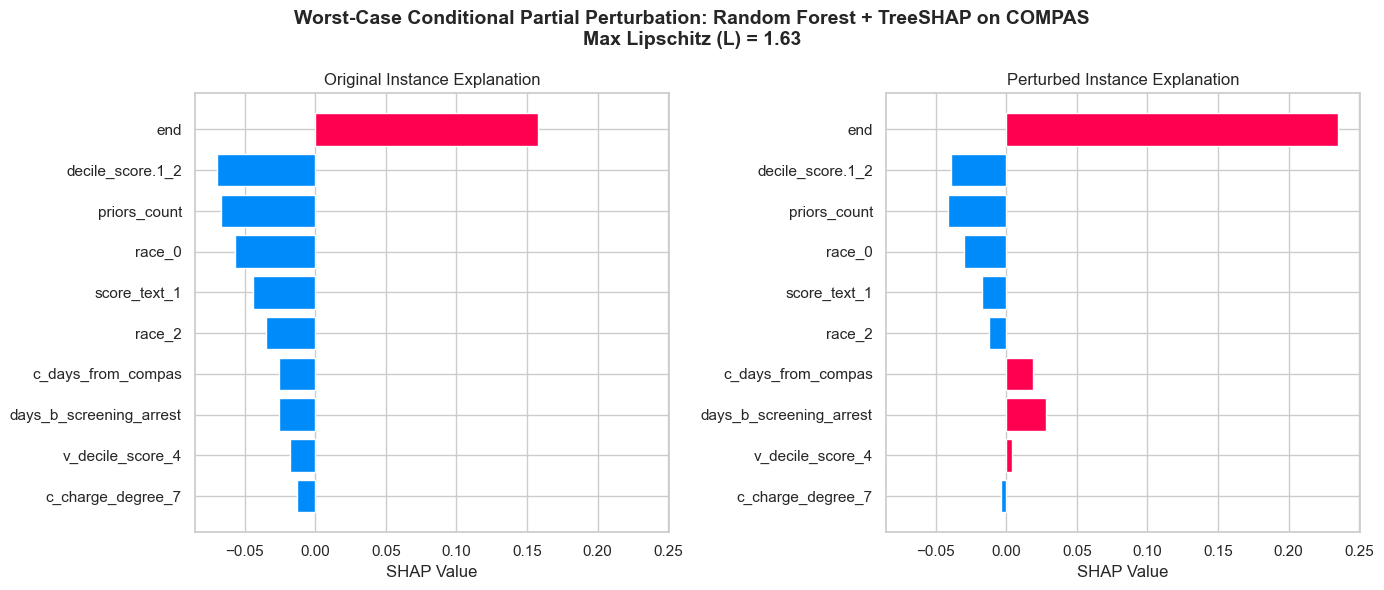

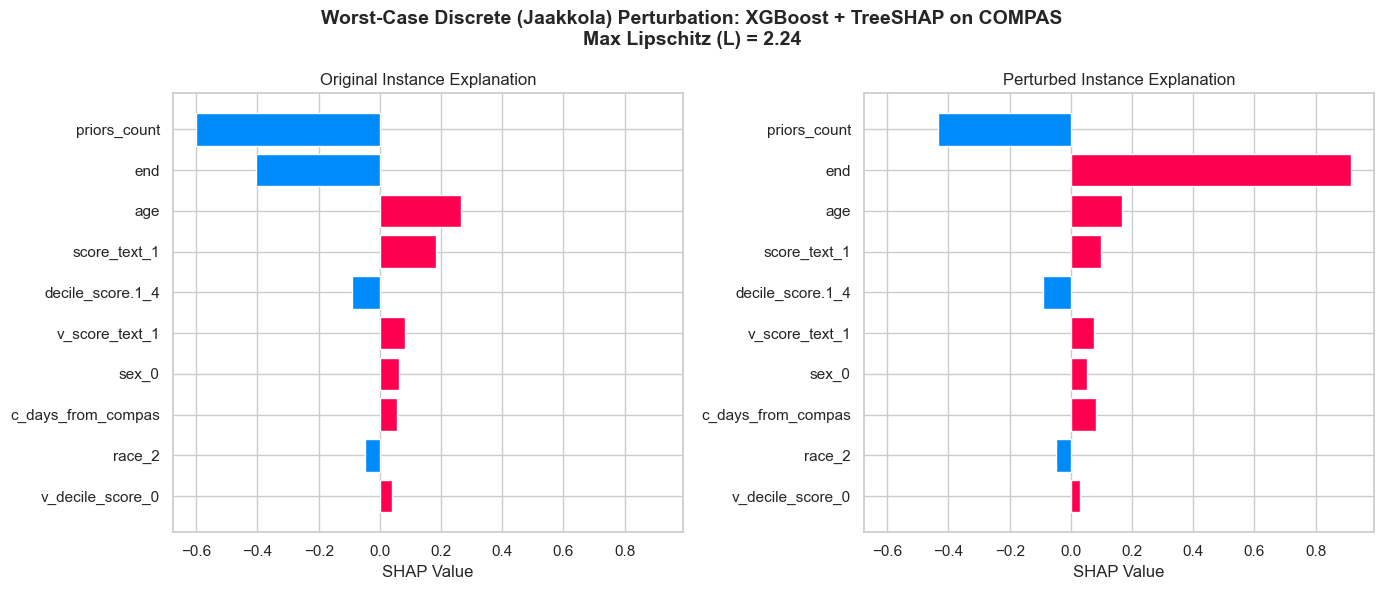

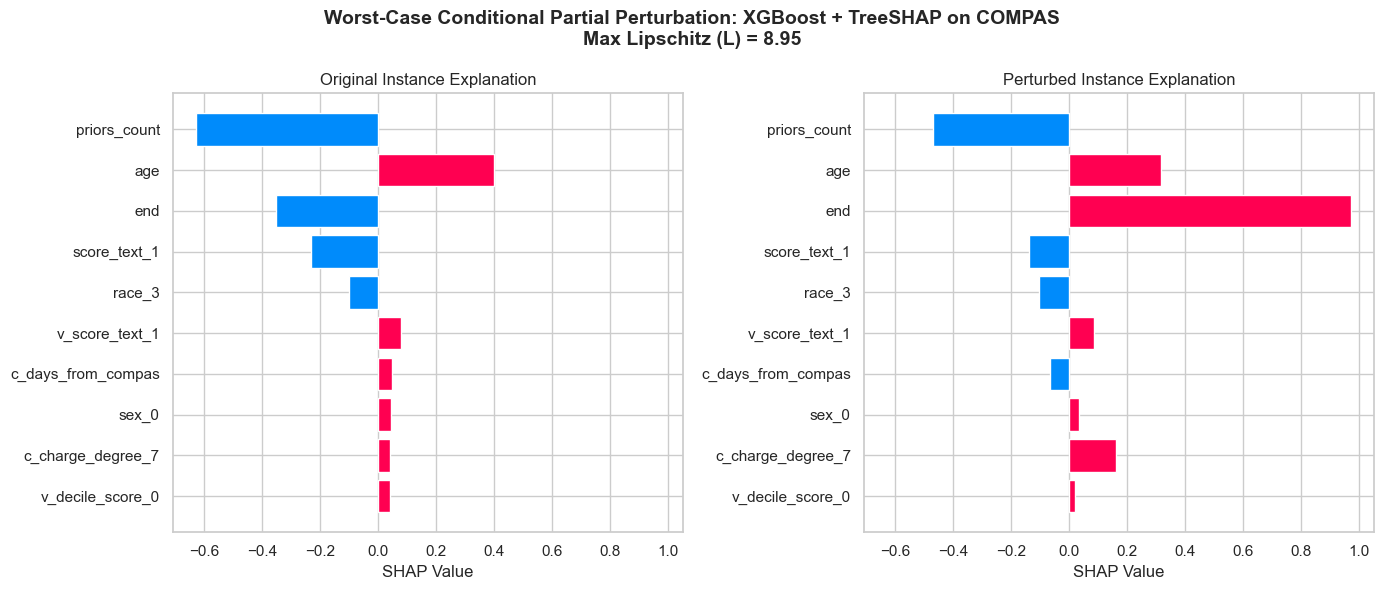

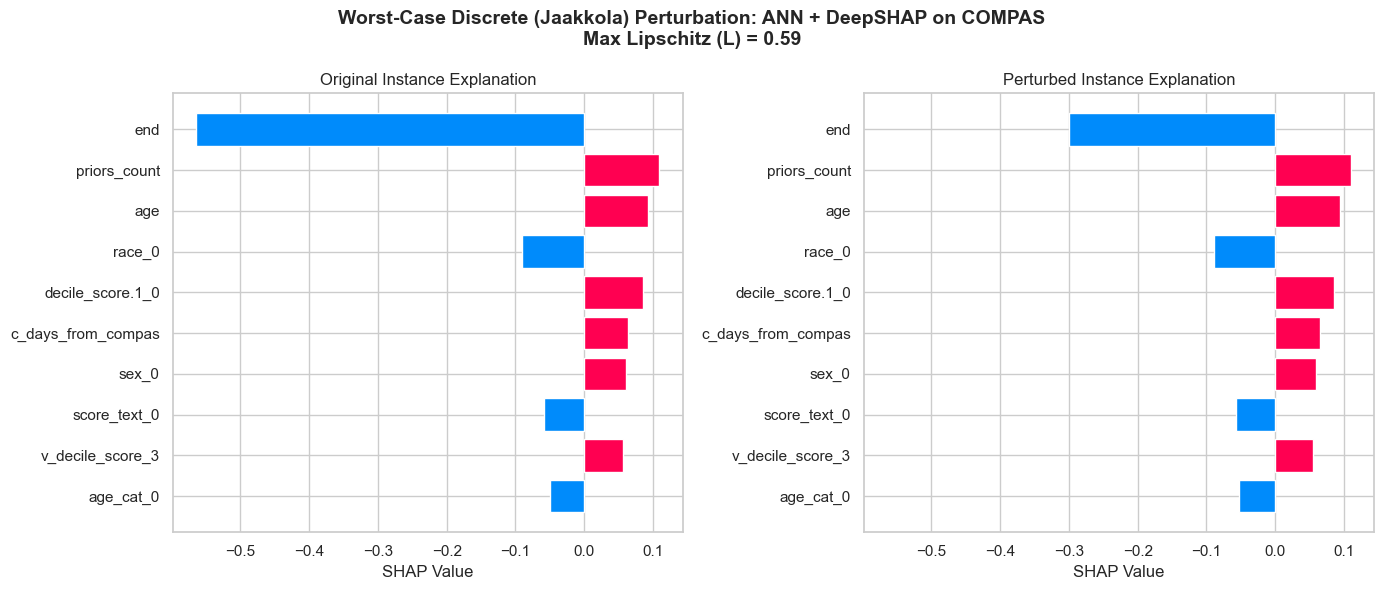

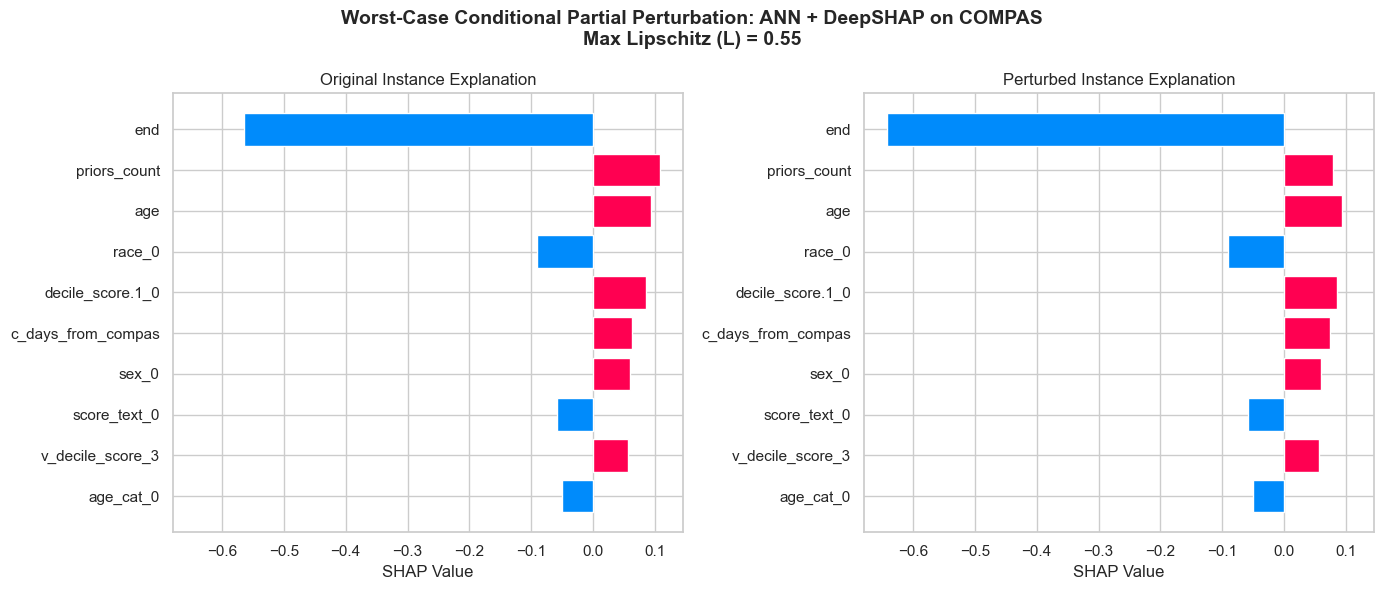


Loading ADULT dataset...
  -> Tuning Models...
  -> Initializing Explainers...
  -> Finding worst-case explanations for ADULT...


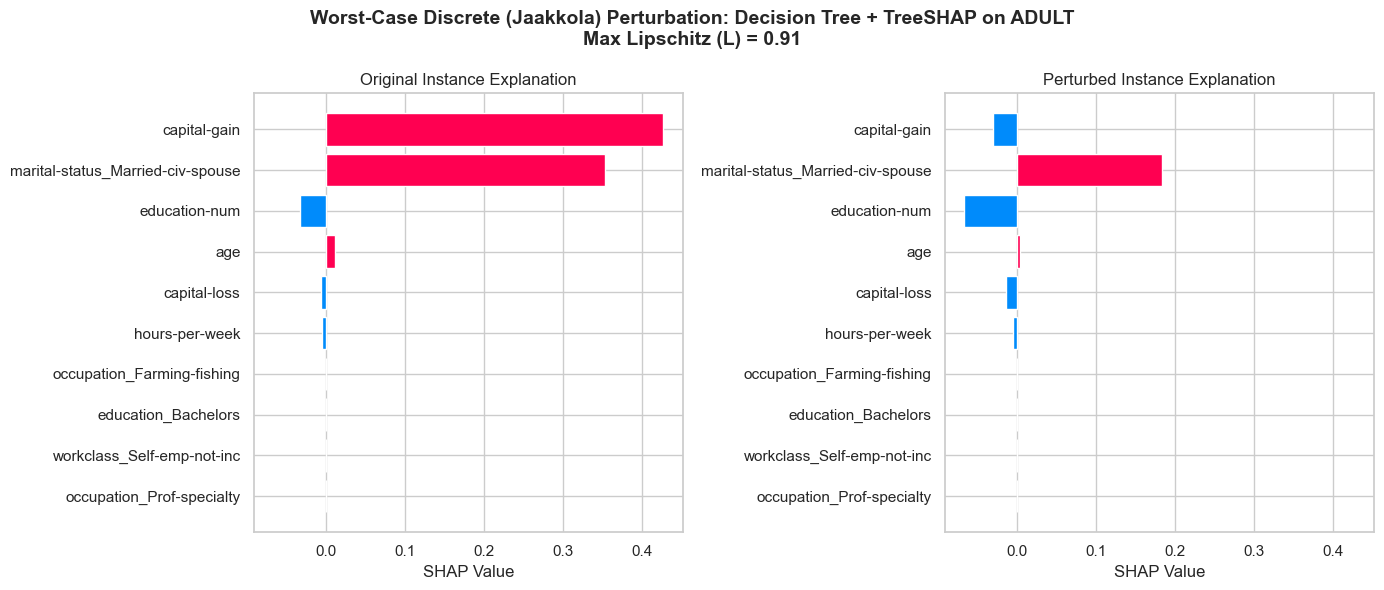

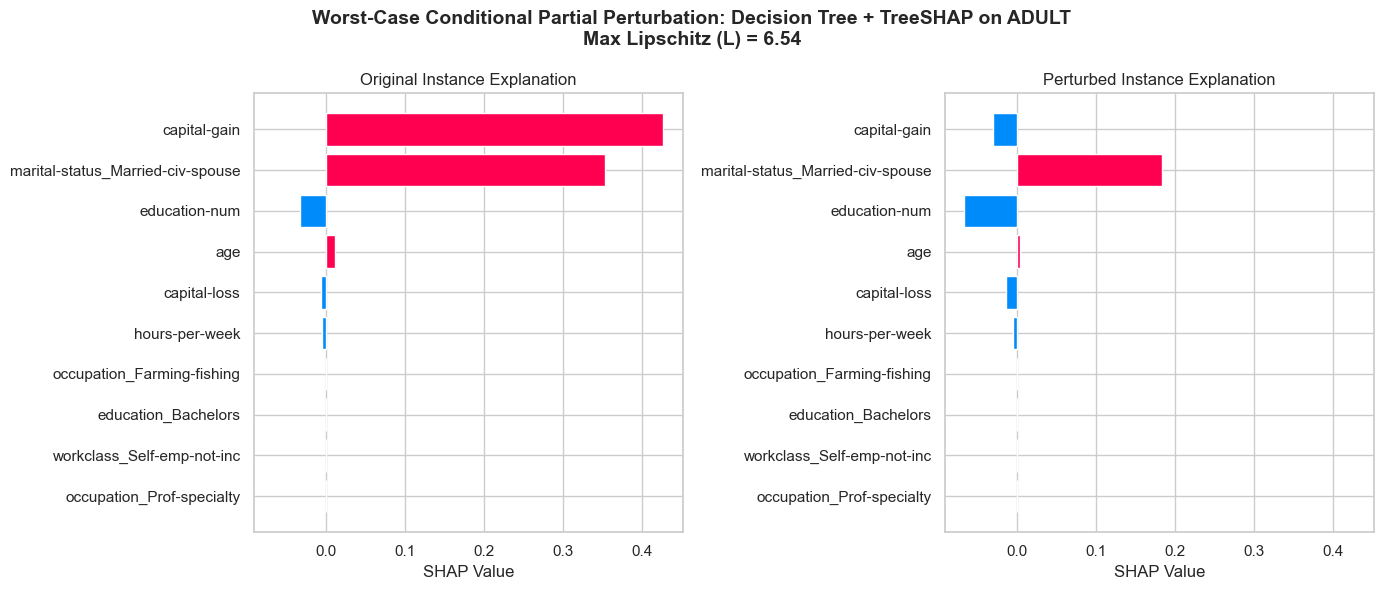

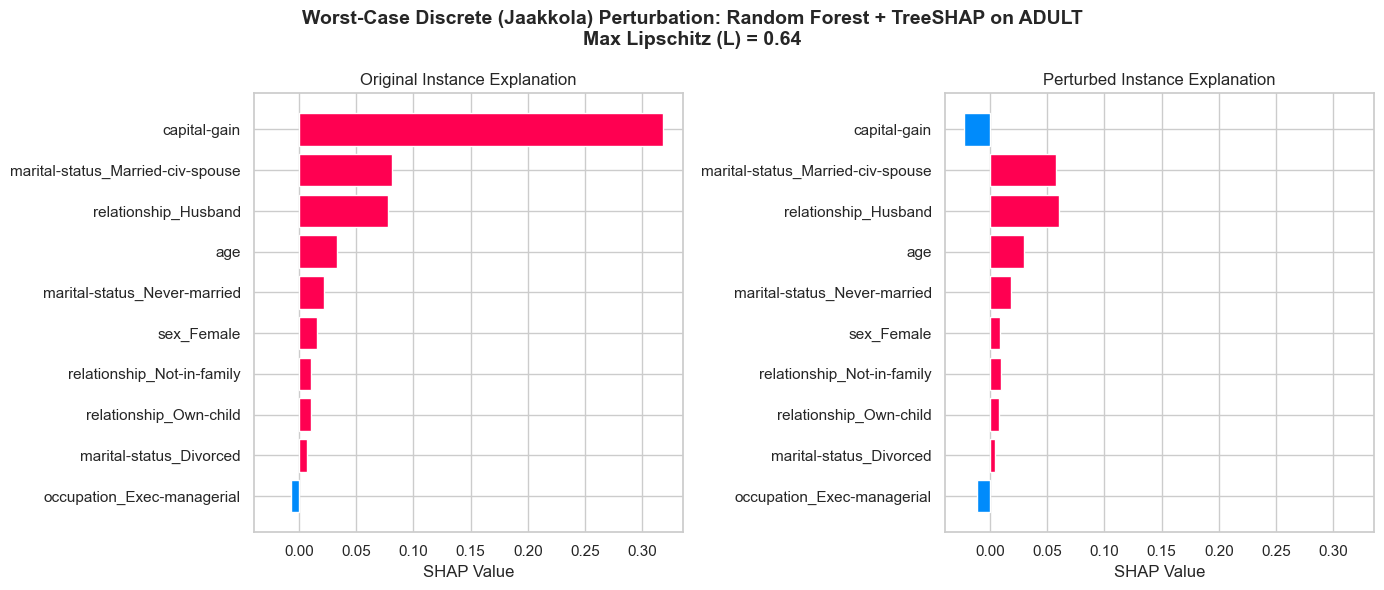

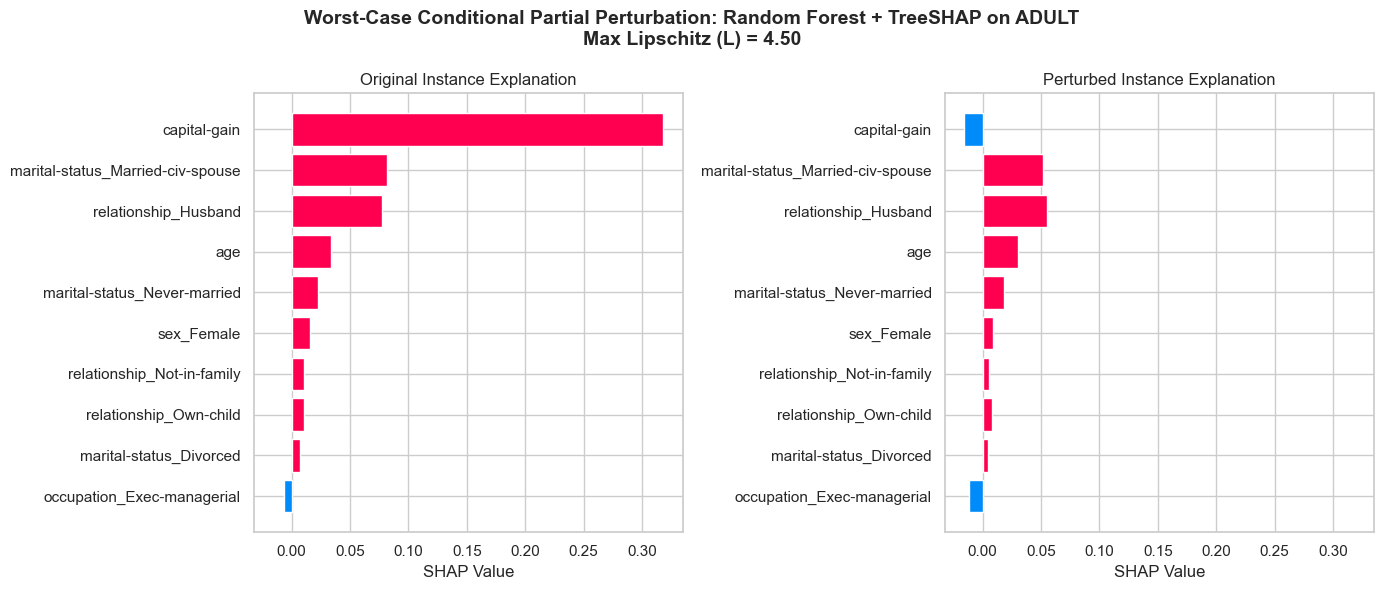

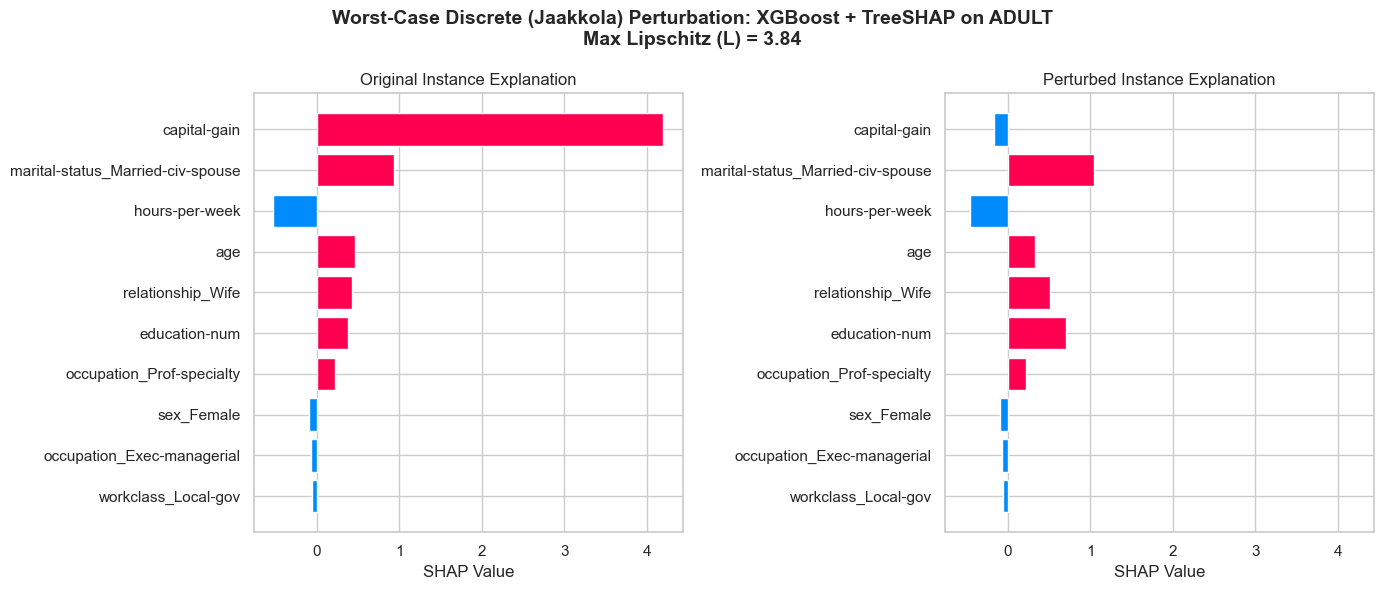

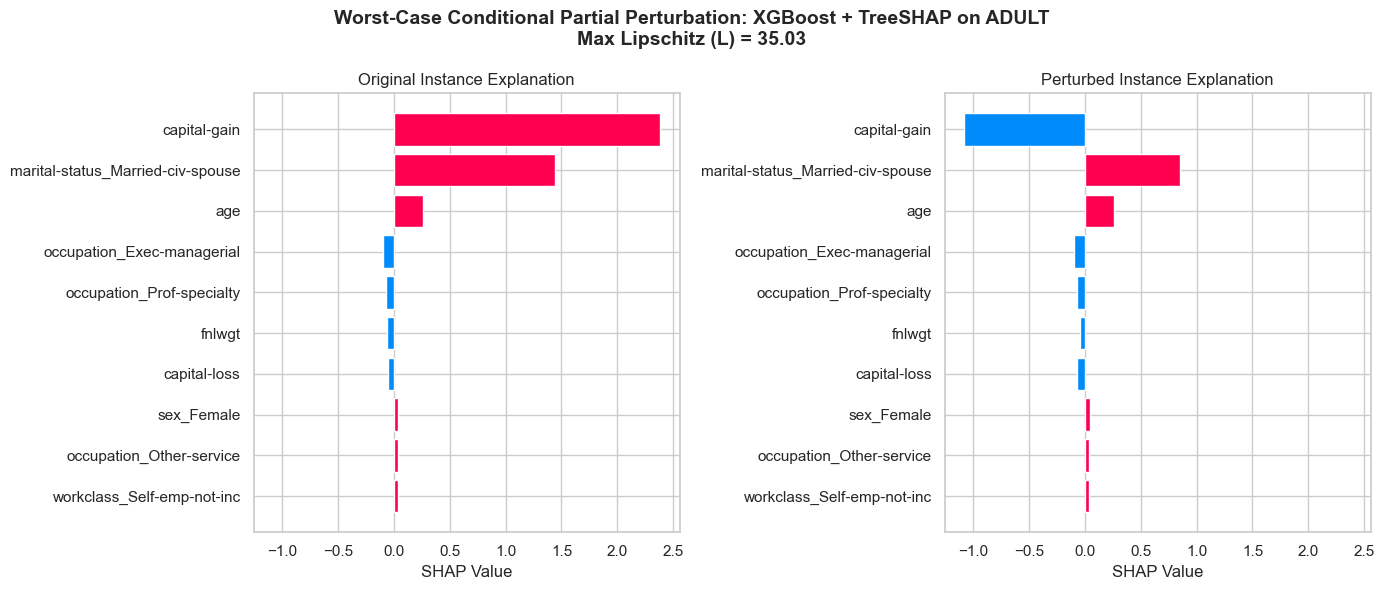

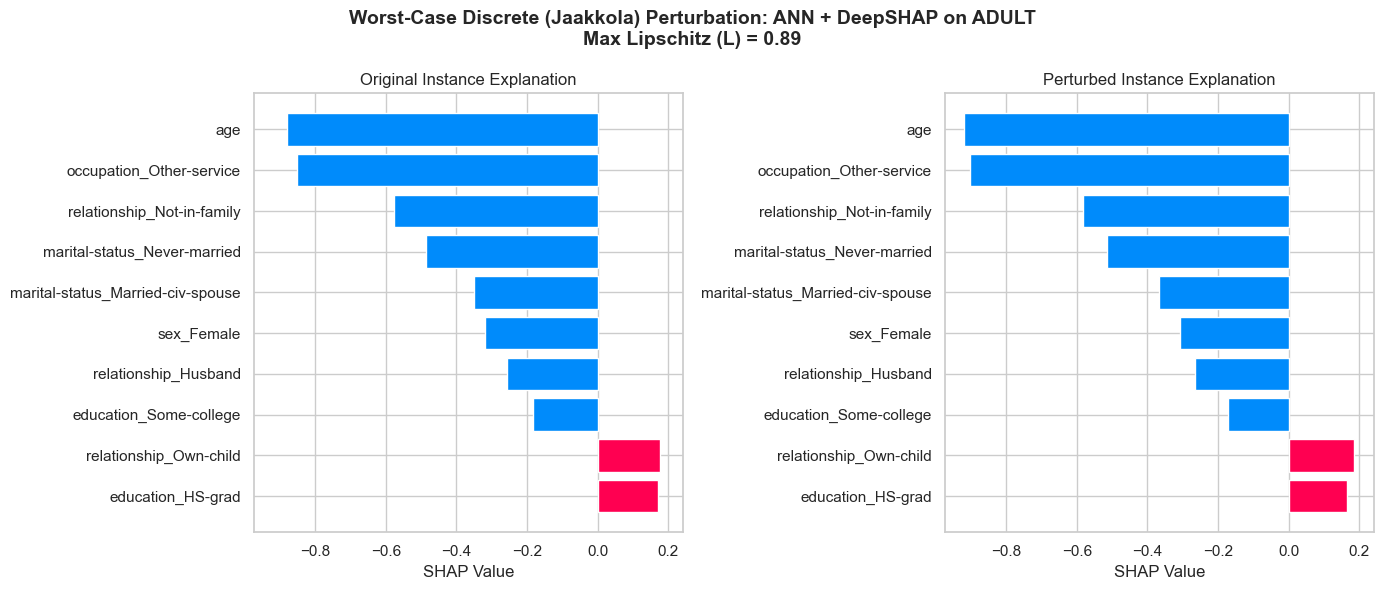

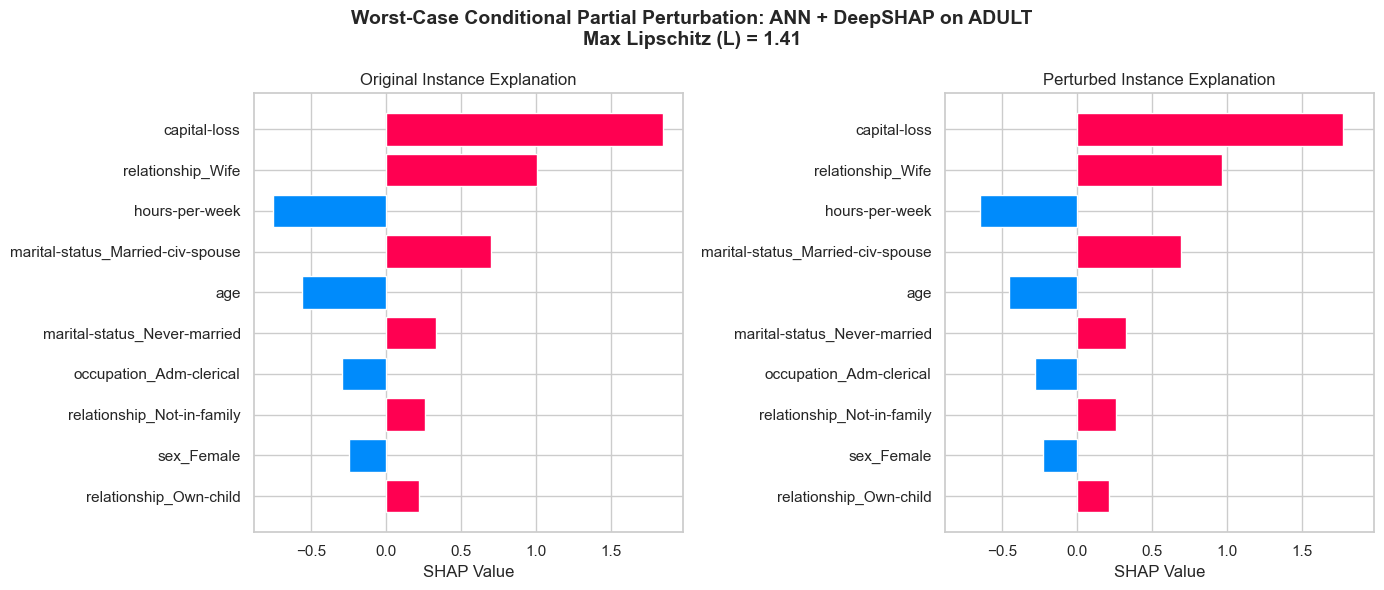


Loading GERMAN dataset...
  -> Tuning Models...
  -> Initializing Explainers...
  -> Finding worst-case explanations for GERMAN...


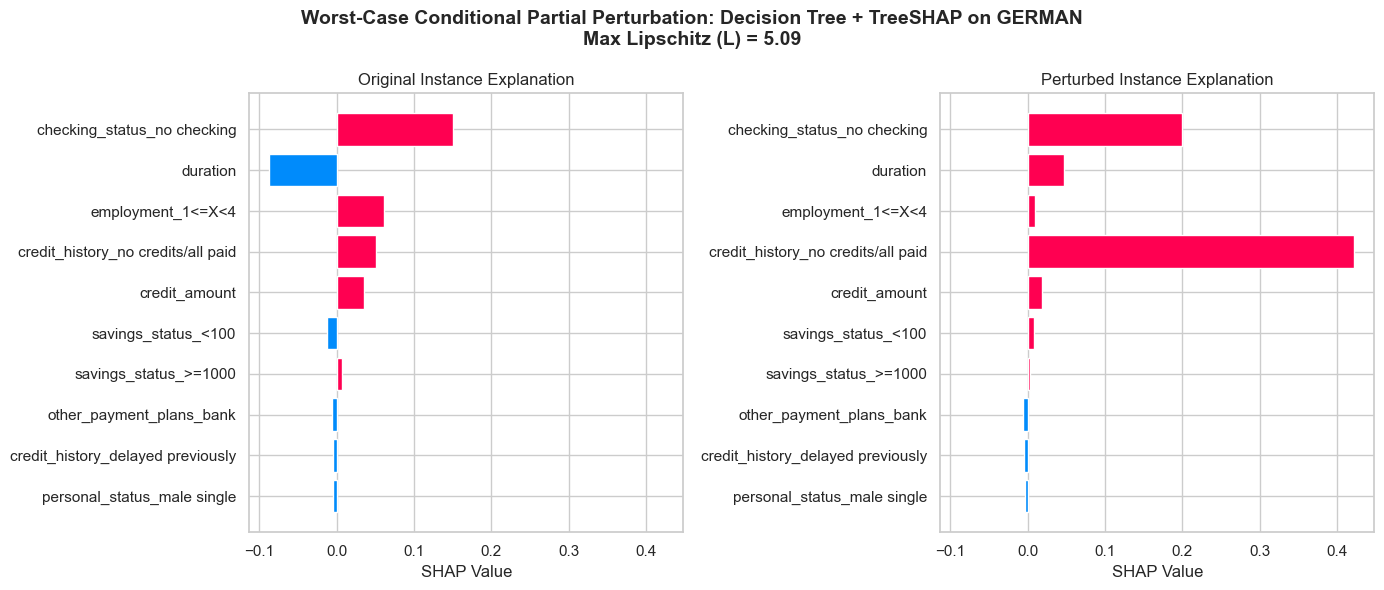

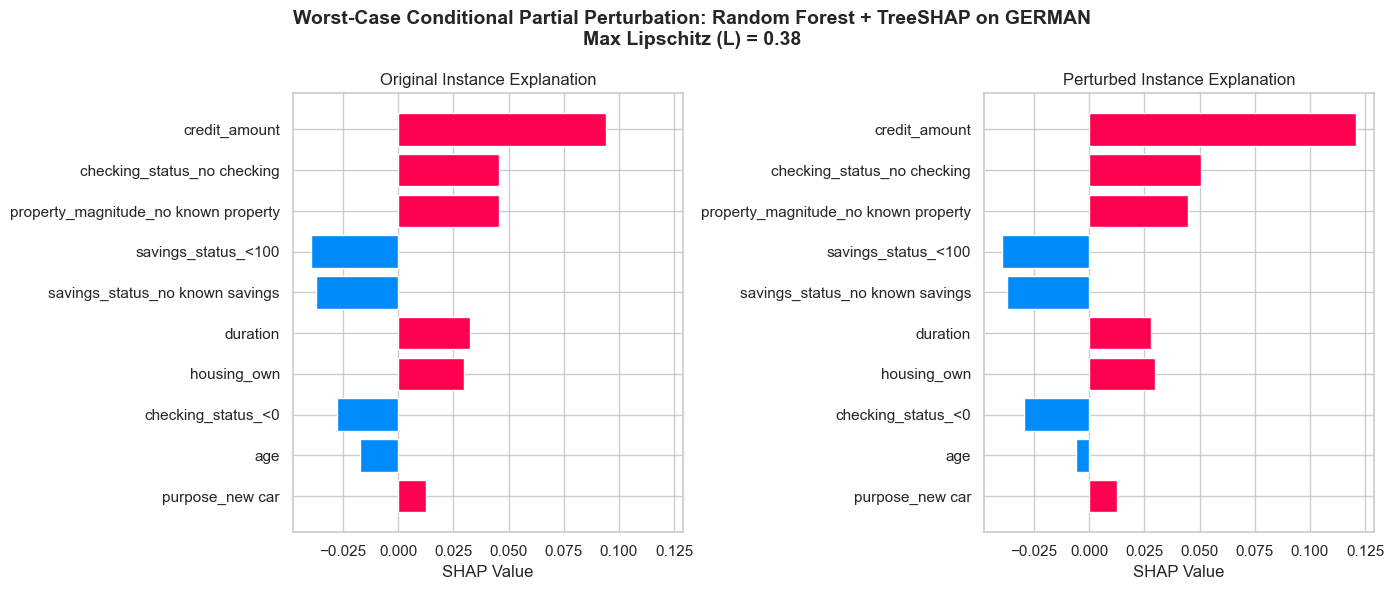

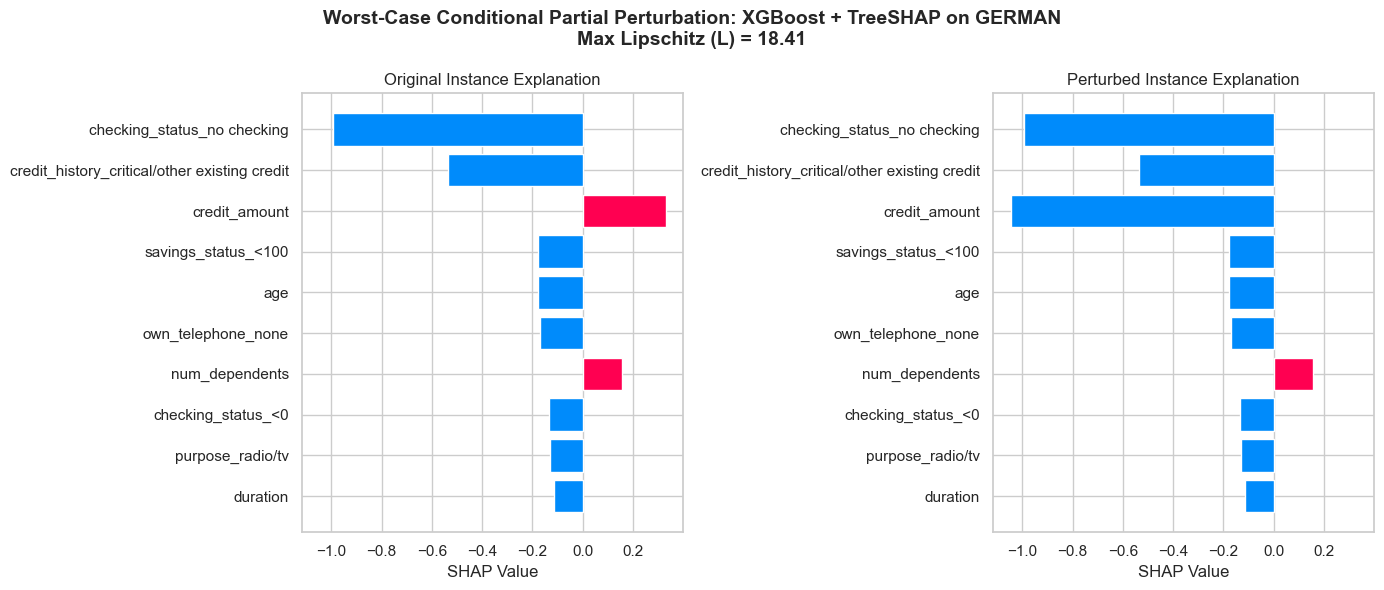

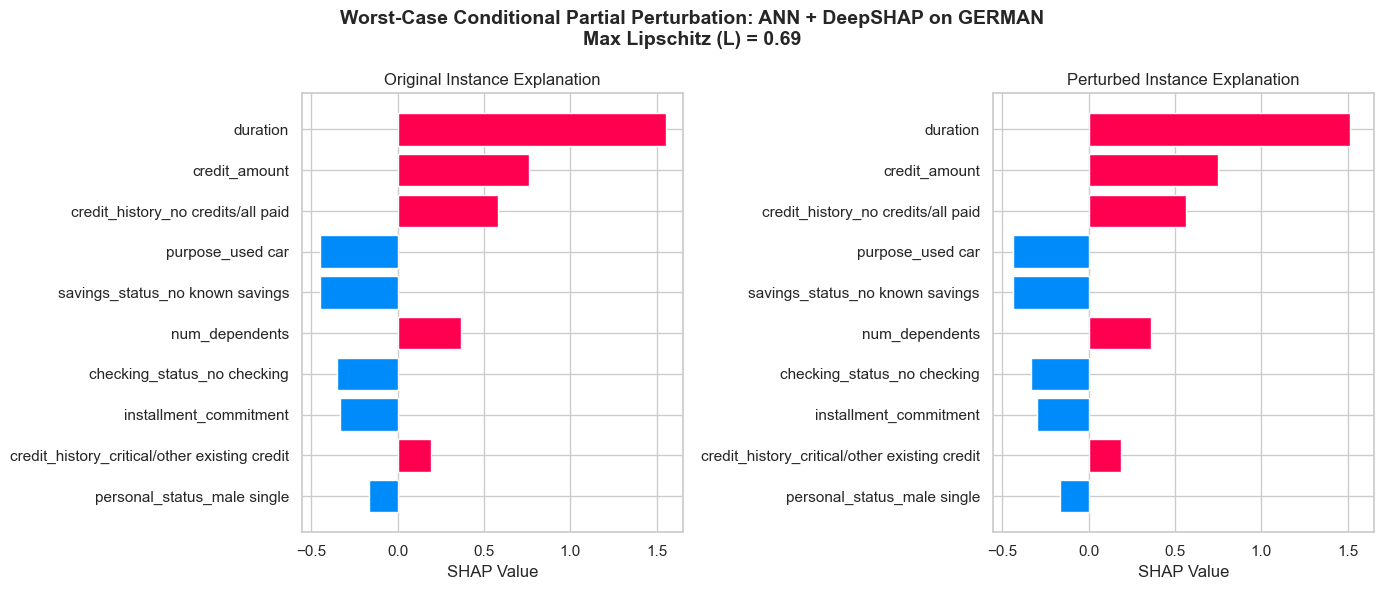

In [3]:
import os
import random
import numpy as np
import pandas as pd
import warnings
import time

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
import shap

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ==========================================
# 0. RIGOROUS REPRODUCIBILITY (The Ironclad Fix)
# ==========================================
def seed_everything(seed=42):
    """
    Locks down all sources of randomness across Python, OS, NumPy, and PyTorch
    to ensure 100% identical results on every run for academic publishing.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Execute the seed lockdown immediately
seed_everything(42)

# ==========================================
# 1. EXPERIMENT HYPERPARAMETERS
# ==========================================
EPSILON_CONTINUOUS = 0.05   
EPSILON_DISCRETE = 1.5      
K_PERTURBATIONS = 100       
N_EVAL_SAMPLES = 15         
CV_FOLDS = 3                

FIGURES_DIR = "paper_figures"
os.makedirs(FIGURES_DIR, exist_ok=True)


# ==========================================
# 2. DATA PREPROCESSING (Bug Fixed)
# ==========================================
def load_and_preprocess_data(dataset_name):             
    openml_ids = {"taiwan": 42477, "compas": 44162, "adult": 1590, "german": 31}
    if dataset_name not in openml_ids: raise ValueError(f"Dataset {dataset_name} not supported.")
        
    print(f"\nLoading {dataset_name.upper()} dataset...")
    dataset = fetch_openml(data_id=openml_ids[dataset_name], as_frame=True, parser='auto')
    df = dataset.frame.dropna()
    target_col = dataset.target_names[0]

    X_raw = df.drop(columns=[target_col])
    y = pd.factorize(df[target_col])[0] if df[target_col].dtype in ['category', 'object'] else df[target_col].astype(int).values

    continuous_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X_raw.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()
    X = X_raw[continuous_cols + categorical_cols]

    # random_state ensures the exact same data split
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

    X_train = preprocessor.fit_transform(X_train_raw)
    X_test = preprocessor.transform(X_test_raw)
    
    # FIX: Safety check for datasets (like Taiwan) that have no categorical features
    if len(categorical_cols) > 0:
        cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    else:
        cat_feature_names = []
        
    feature_names = continuous_cols + list(cat_feature_names)
    
    continuous_indices = list(range(len(continuous_cols)))
    feature_stds = X_train[:, continuous_indices].std(axis=0) if len(continuous_indices) > 0 else []
    
    return X_train, X_test, y_train, y_test, continuous_indices, feature_stds, feature_names





# ==========================================
# 3. TUNING ALGORITHMS
# ==========================================
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

def tune_tree_models(X_train, y_train):
    print("  -> Tuning Models...")
    # Decision Tree and RF are fine with n_jobs=-1
    dt = GridSearchCV(DecisionTreeClassifier(random_state=42), {'max_depth': [5, 10, None]}, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1).fit(X_train, y_train)
    rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), {'n_estimators': [50], 'max_depth': [10, None]}, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1).fit(X_train, y_train)
    
    # FIX: XGBoost set to n_jobs=1 to prevent parallel threading race conditions from altering tree structures
    xgb_m = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=1), {'n_estimators': [50], 'max_depth': [3, 6]}, cv=cv_strategy, scoring='neg_log_loss', n_jobs=1).fit(X_train, y_train)
    
    return dt.best_estimator_, rf.best_estimator_, xgb_m.best_estimator_

class DynamicANN(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        for h in hidden_dims: layers.extend([nn.Linear(input_dim, h), nn.ReLU()]); input_dim = h
        layers.append(nn.Linear(input_dim, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def tune_ann(X_train, y_train, input_dim):
    X_t, X_v, y_t, y_v = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    model = DynamicANN(input_dim, [32, 16])
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCEWithLogitsLoss()
    for _ in range(20):
        model.train()
        optimizer.zero_grad()
        criterion(model(torch.tensor(X_t, dtype=torch.float32)), torch.tensor(y_t, dtype=torch.float32).unsqueeze(1)).backward()
        optimizer.step()
    model.eval()
    return model

# ==========================================
# 4. LIPSCHITZ MATHEMATICS
# ==========================================
def calculate_discrete_lipschitz(x_inst, X_test_pool, exp_x, explainer_fn, eps_d):
    distances = np.linalg.norm(X_test_pool - x_inst, axis=1)
    neighbors = np.where((distances > 1e-9) & (distances <= eps_d))[0]
    if len(neighbors) == 0: return np.nan, None, None
    
    dist_x = distances[neighbors]
    exp_neighbors = explainer_fn(X_test_pool[neighbors])
    dist_exp = np.linalg.norm(exp_neighbors - exp_x, axis=1)
    
    lipschitz_vals = dist_exp / dist_x
    max_idx = np.argmax(lipschitz_vals) 
    
    return lipschitz_vals[max_idx], X_test_pool[neighbors[max_idx]], exp_neighbors[max_idx]

def calculate_partial_lipschitz(x_inst, exp_x, explainer_fn, cont_idx, feat_stds, eps_c, k):
    if len(cont_idx) == 0: return np.nan, None, None
    x_pert = np.tile(x_inst, (k, 1)).astype(float)
    for i, idx in enumerate(cont_idx):
        x_pert[:, idx] += np.random.normal(0, eps_c * feat_stds[i], k)
        
    dist_x = np.linalg.norm(x_pert - x_inst, axis=1) + 1e-9
    exp_pert = explainer_fn(x_pert)
    dist_exp = np.linalg.norm(exp_pert - exp_x, axis=1)
    
    lipschitz_vals = dist_exp / dist_x
    max_idx = np.argmax(lipschitz_vals) 
    
    return lipschitz_vals[max_idx], x_pert[max_idx], exp_pert[max_idx]

# ==========================================
# 5. WORST-CASE VISUALIZATIONS 
# ==========================================
def plot_worst_case_explanations(orig_x, pert_x, orig_exp, pert_exp, feature_names, model_name, metric_name, L_val, dataset_name):
    sns.set_theme(style="whitegrid")
    
    top_indices = np.argsort(np.abs(orig_exp))[-10:]
    plot_feats = [feature_names[i] for i in top_indices]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
    fig.suptitle(f"Worst-Case {metric_name} Perturbation: {model_name} on {dataset_name.upper()}\nMax Lipschitz (L) = {L_val:.2f}", fontsize=14, fontweight='bold')
    
    axes[0].barh(plot_feats, orig_exp[top_indices], color=np.where(orig_exp[top_indices] > 0, '#ff0051', '#008bfb'))
    axes[0].set_title("Original Instance Explanation")
    axes[0].set_xlabel("SHAP Value")
    
    axes[1].barh(plot_feats, pert_exp[top_indices], color=np.where(pert_exp[top_indices] > 0, '#ff0051', '#008bfb'))
    axes[1].set_title("Perturbed Instance Explanation")
    axes[1].set_xlabel("SHAP Value")
    
    plt.tight_layout()
    
    safe_model_name = model_name.replace(" + ", "_").replace(" ", "_")
    safe_metric_name = "Discrete" if "Discrete" in metric_name else "Partial"
    filename = f"{FIGURES_DIR}/{dataset_name}_{safe_model_name}_{safe_metric_name}_WorstCase.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()

# ==========================================
# 6. MASTER EVALUATION LOOP
# ==========================================
def run_metric_comparison(dataset_name):
    X_train, X_test, y_train, y_test, cont_indices, feat_stds, feature_names = load_and_preprocess_data(dataset_name)
    input_dim = X_train.shape[1]
    
    dt, rf, xgb_m = tune_tree_models(X_train, y_train)
    ann = tune_ann(X_train, y_train, input_dim)

    print("  -> Initializing Explainers...")
    tree_exp_dt = shap.TreeExplainer(dt)
    tree_exp_rf = shap.TreeExplainer(rf)
    tree_exp_xgb = shap.TreeExplainer(xgb_m)
    
    # Randomness checkpoint: SHAP background sampling
    np.random.seed(42) 
    background_data = torch.tensor(shap.sample(X_train, 100, random_state=42), dtype=torch.float32)
    deep_exp_ann = shap.DeepExplainer(ann, background_data)
    
    def shape_fix(sv): 
        if isinstance(sv, list): return np.array(sv[-1])
        if len(sv.shape) == 3: return sv[:, :, -1]
        return sv

    wrappers = {
        "Decision Tree + TreeSHAP": lambda X: shape_fix(tree_exp_dt.shap_values(X)),
        "Random Forest + TreeSHAP": lambda X: shape_fix(tree_exp_rf.shap_values(X)),
        "XGBoost + TreeSHAP": lambda X: shape_fix(tree_exp_xgb.shap_values(X)),
        "ANN + DeepSHAP": lambda X: shape_fix(deep_exp_ann.shap_values(torch.tensor(X, dtype=torch.float32)))
    }

    # Randomness checkpoint: Exact same test instances evaluated every time
    np.random.seed(42) 
    eval_indices = np.random.choice(len(X_test), N_EVAL_SAMPLES, replace=False)
    
    print(f"  -> Finding worst-case explanations for {dataset_name.upper()}...")

    for model_name, wrapper in wrappers.items():
        worst_disc_L, worst_disc_data = 0, None
        worst_part_L, worst_part_data = 0, None
        
        # Randomness checkpoint: Re-seeding right before the perturbation loop
        # This guarantees the synthetic Gaussian noise is identical for every model
        np.random.seed(42) 

        for idx in eval_indices:
            x_inst = X_test[idx:idx+1]
            exp_base = wrapper(x_inst)[0]
            
            # Discrete
            l_disc, x_pert_disc, exp_pert_disc = calculate_discrete_lipschitz(x_inst, X_test, exp_base, wrapper, EPSILON_DISCRETE)
            if not np.isnan(l_disc) and l_disc > worst_disc_L:
                worst_disc_L = l_disc
                worst_disc_data = (x_inst[0], x_pert_disc, exp_base, exp_pert_disc)
                
            # Partial
            l_part, x_pert_part, exp_pert_part = calculate_partial_lipschitz(x_inst, exp_base, wrapper, cont_indices, feat_stds, EPSILON_CONTINUOUS, K_PERTURBATIONS)
            if not np.isnan(l_part) and l_part > worst_part_L:
                worst_part_L = l_part
                worst_part_data = (x_inst[0], x_pert_part, exp_base, exp_pert_part)

        if worst_disc_data:
            plot_worst_case_explanations(worst_disc_data[0], worst_disc_data[1], worst_disc_data[2], worst_disc_data[3], 
                                         feature_names, model_name, "Discrete (Jaakkola)", worst_disc_L, dataset_name)
        if worst_part_data:
            plot_worst_case_explanations(worst_part_data[0], worst_part_data[1], worst_part_data[2], worst_part_data[3], 
                                         feature_names, model_name, "Conditional Partial", worst_part_L, dataset_name)

if __name__ == "__main__":
    datasets_to_run = ["taiwan", "compas", "adult", "german"]
    for ds in datasets_to_run:
        run_metric_comparison(ds)